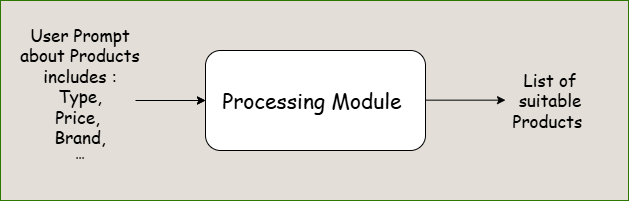

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q huggingface_hub

In [ ]:
import os
import shutil
from huggingface_hub import hf_hub_download
import pandas as pd

REPO_ID = "RadeAI/Digikala_comments_products"

products_path = hf_hub_download(repo_id=REPO_ID, filename="digikala-products.csv", repo_type="dataset")
comments_path = hf_hub_download(repo_id=REPO_ID, filename="digikala-comments.csv", repo_type="dataset")

drive_folder = '/content/drive/MyDrive/digikala_project'
os.makedirs(drive_folder, exist_ok=True)

shutil.copy(products_path, os.path.join(drive_folder, 'digikala-products.csv'))
shutil.copy(comments_path, os.path.join(drive_folder, 'digikala-comments.csv'))

print("Copied to :", drive_folder)

digikala-products.csv: reconstructing file:   0%|          |  0.00B /  259MB            

digikala-products.csv: downloading bytes:           |  0.00B            

digikala-comments.csv: reconstructing file:   0%|          |  0.00B / 1.28GB            

digikala-comments.csv: downloading bytes:           |  0.00B            

Copied to : /content/drive/MyDrive/digikala_project


In [ ]:
# Next time
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil
from huggingface_hub import hf_hub_download
import pandas as pd

REPO_ID = "RadeAI/Digikala_comments_products"
import pandas as pd
drive_folder = '/content/drive/MyDrive/digikala_project'

products = pd.read_csv(os.path.join(drive_folder, 'digikala-products.csv'))
comments = pd.read_csv(os.path.join(drive_folder, 'digikala-comments.csv'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_2657/3367418581.py:14: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  products = pd.read_csv(os.path.join(drive_folder, 'digikala-products.csv'))


In [ ]:
# ======================================
# Improved TF-IDF Search Preparation
# ======================================

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# -------------------------------
# 1) Better search text
# -------------------------------

products["search_text"] = (
    (
        products["title_fa"]
        .astype(str)
        + " "
    ) * 3
    +
    products["Category1"]
    .astype(str)
    + " "
    +
    products["Category2"]
    .astype(str)
    + " "
    +
    products["Brand"]
    .astype(str)
)


print(products["search_text"].head(3))


# -------------------------------
# 2) Build TF-IDF
# -------------------------------

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=2
)


tfidf_matrix = vectorizer.fit_transform(
    products["search_text"]
)


print(
    "TF-IDF shape:",
    tfidf_matrix.shape
)



# -------------------------------
# 3) Improved Search Function
# -------------------------------

def search_products(
    query,
    price_max=None,
    brand=None,
    top_k=5,
    w_text=0.65,
    w_satisfaction=0.25,
    w_popularity=0.10
):

    # Query vector
    query_vec = vectorizer.transform(
        [query]
    )


    # Similarity score
    sim_scores = cosine_similarity(
        query_vec,
        tfidf_matrix
    ).flatten()


    result = products.copy()

    result["text_score"] = sim_scores

    # -------------------------------
    # Category-aware filtering
    # -------------------------------

    query_lower = query.lower()


    category_keywords = {
        "کیف": ["کیف"],
        "کفش": ["کفش"],
        "گوشی": ["گوشی", "موبایل"],
        "لپ تاپ": ["لپ تاپ", "لپ‌تاپ"],
        "ساعت": ["ساعت"],
        "لباس": ["لباس"],
    }


    for keyword, cats in category_keywords.items():

        if keyword in query_lower:

            mask = False

            for cat in cats:
                mask = mask | (
                    result["Category1"]
                    .astype(str)
                    .str.contains(
                        cat,
                        na=False
                    )
                )

                mask = mask | (
                    result["Category2"]
                    .astype(str)
                    .str.contains(
                        cat,
                        na=False
                    )
                )

            result = result[mask]

            break



    # Price filtering
    if price_max is not None:
        result = result[
            result["Price"] <= price_max
        ]



    # Brand filtering
    if brand:
        result = result[
            result["Brand"]
            .str.contains(
                brand,
                case=False,
                na=False
            )
        ]



    # Remove irrelevant products
    result = result[
        result["text_score"] > 0
    ]


    if len(result)==0:
        return None



    # Final ranking

    result["final_score"] = (
        w_text * result["text_score"]
        +
        w_satisfaction * result["satisfaction_norm"]
        +
        w_popularity * result["popularity_norm"]
    )


    result = result.sort_values(
        "final_score",
        ascending=False
    )


    return result[
        [
            "id",
            "title_fa",
            "Brand",
            "Category1",
            "Price",
            "Rate",
            "Rate_cnt",
            "satisfaction_score",
            "final_score"
        ]
    ].head(top_k)

0    آبسلانگ مدل s5 بسته 250 عددی آبسلانگ مدل s5 بس...
1     آبسلانگ مدل M-1 بسته 400 عددی  آبسلانگ مدل M-...
2    آبسلانگ مدل m50 مجموعه 500 عددی آبسلانگ مدل m5...
Name: search_text, dtype: object
TF-IDF shape: (948352, 50000)


In [ ]:
result = search_products(
    "کیف روزمره",
    price_max=1000000,
    top_k=5
)

result

,id,title_fa,Brand,Category1,Price,Rate,Rate_cnt,satisfaction_score,final_score
244743,2943384,کیف مدارک کد 0573,متفرقه,اکسسوری زنانه و مردانه,563200,82,525,77.514242,0.407585
198919,2058369,کیف دوشی زنانه مدل روشا,متفرقه,اکسسوری زنانه,730000,78,6183,77.618272,0.402403
198976,3617686,کیف رودوشی زنانه مدل SH1113,متفرقه,اکسسوری زنانه,980000,82,320,75.028890,0.402126
198903,2551931,کیف دستی زنانه مدل 0044,متفرقه,اکسسوری زنانه,350000,82,943,79.402507,0.386671
321422,1865629,کیف کمری مردانه کد 226310,متفرقه,اکسسوری مردانه,930400,82,647,78.299411,0.385552


# Previous vers :

In [ ]:
print(products.head(3))
print("\n--- columns & nulls ---")
print(products.isnull().sum())
print("\n--- dtypes ---")
print(products.dtypes)

        id                         title_fa  Rate  Rate_cnt Category1  \
0  7096438     آبسلانگ مدل s5 بسته 250 عددی    90         4   آبسلانگ   
1  2845119    آبسلانگ مدل M-1 بسته 400 عددی    84       217   آبسلانگ   
2  6117745  آبسلانگ مدل m50 مجموعه 500 عددی    88        14   آبسلانگ   

  Category2   Brand   Price         Seller  Is_Fake  min_price_last_month  \
0       NaN  متفرقه  634800  سلامت ساز راد    False                     0   
1       NaN  متفرقه  818800      مهر افزون    False                     0   
2       NaN  متفرقه  920000         یانگوم    False                     0   

  sub_category  
0       beauty  
1       beauty  
2       beauty  

--- columns & nulls ---
id                           0
title_fa                     0
Rate                         0
Rate_cnt                     0
Category1                    0
Category2               210108
Brand                        0
Price                        0
Seller                     223
Is_Fake                   

In [ ]:
print(products['Category1'].value_counts().head(20))
print("\n---")
print(products['Category2'].value_counts().head(20))

Category1
اکسسوری زنانه و مردانه          95999
لباس زنانه                      93392
اسباب بازی                      92466
لباس مردانه                     68178
اکسسوری زنانه                   64470
اکسسوری مردانه                  49383
دخترانه                         42931
دفتر و کاغذ و مقوا              42864
زیورآلات طلا زنانه              41098
کتاب چاپی غیر فارسی             39409
مراقبت پوست                     29662
مواد غذایی                      28930
پسرانه                          27066
کتاب شعر و ادبیات               23345
برس‌ها و تجهیزات آرایشی         22749
محصولات سنگی، چینی و سرامیکی    22599
کفش مردانه                      20435
مد و پوشاک دخترانه و پسرانه     19861
کفش زنانه                       18396
نوزاد                           18324
Name: count, dtype: int64

---
Category2
فکری و آموزشی                   46767
دفتر                            38459
زیورآلات زنانه و مردانه         35086
لباس دخترانه                    26752
لباس ورزشی زنانه                23009

In [ ]:
# سلول ۴: تمیزکاری سریع و آماده‌سازی
import numpy as np

# محصولاتی که Rate_cnt خیلی کمه رو کنار نمی‌ذاریم ولی توی امتیازدهی جریمه می‌شن (پایین‌تر)

# پر کردن دسته‌بندی خالی برای جست‌وجوی متنی
products['Category2'] = products['Category2'].fillna('')
products['search_text'] = (
    products['title_fa'].astype(str) + ' ' +
    products['Category1'].astype(str) + ' ' +
    products['Category2'].astype(str) + ' ' +
    products['sub_category'].astype(str)
)

print(products['search_text'].head(3).tolist())

['آبسلانگ مدل s5 بسته 250 عددی آبسلانگ  beauty', ' آبسلانگ مدل M-1 بسته 400 عددی آبسلانگ  beauty', 'آبسلانگ مدل m50 مجموعه 500 عددی آبسلانگ  beauty']


In [ ]:
# سلول ۵: محاسبه‌ی امتیاز رضایت (Bayesian average)
# چرا Bayesian: محصولی با ۲ رأی و امتیاز ۱۰۰ نباید از محصولی با ۵۰۰۰ رأی و امتیاز ۹۵ بهتر باشه

C = products['Rate'].mean()          # میانگین کلی امتیاز همه‌ی محصولات
m = products['Rate_cnt'].quantile(0.6)  # حداقل تعداد رأی برای اعتماد کامل (قابل تنظیم)

def bayesian_score(row):
    v = row['Rate_cnt']
    R = row['Rate']
    return (v / (v + m)) * R + (m / (v + m)) * C

products['satisfaction_score'] = products.apply(bayesian_score, axis=1)

print("C (میانگین کلی):", C, "| m (آستانه):", m)
print(products[['title_fa','Rate','Rate_cnt','satisfaction_score']].sort_values('satisfaction_score', ascending=False).head(5))

/tmp/ipykernel_815/785987963.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (v / (v + m)) * R + (m / (v + m)) * C


C (میانگین کلی): 30.130309716586574 | m (آستانه): 0.0
                                                  title_fa  Rate  Rate_cnt  \
32            ژل ابرو شگلم مدل Set Me Up به همراه برس ابرو   100         3   
392720    کیف نوار بهداشتی مدل دختر و اسب تک شاخ کد IDM500   100         4   
1283185                   پاستیل ترکیبی نات لاین - 400 گرم   100         2   
1283187          شکلات ترافل میکس وانلی نات لاین - 325 گرم   100         3   
998203   کرم مرطوب کننده نیوآ مدل Chilled Oqsis حجم 100...   100         2   

         satisfaction_score  
32                    100.0  
392720                100.0  
1283185               100.0  
1283187               100.0  
998203                100.0  


In [ ]:
# سلول ۶: موتور جست‌وجوی TF-IDF (بدون LLM، بدون pytorch)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(max_features=50000)
tfidf_matrix = vectorizer.fit_transform(products['search_text'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (1283496, 50000)


In [ ]:
# سلول ۷: تابع اصلی جست‌وجو
def search_products(query, price_max=None, top_k=10,
                     w_semantic=0.5, w_satisfaction=0.5):
    # ۱. شباهت معنایی متنی با TF-IDF
    query_vec = vectorizer.transform([query])
    sim_scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    df = products.copy()
    df['semantic_score'] = sim_scores

    # ۲. فیلتر قیمت (اختیاری)
    if price_max is not None:
        df = df[df['Price'] <= price_max]

    # فقط محصولاتی که حداقل کمی شباهت متنی دارن رو نگه می‌داریم
    df = df[df['semantic_score'] > 0]

    if df.empty:
        return df

    # ۳. نرمال‌سازی امتیاز رضایت به بازه‌ی ۰ تا ۱ (چون Rate بین ۰-۱۰۰ است)
    df['satisfaction_norm'] = df['satisfaction_score'] / 100

    # ۴. ترکیب امتیازها
    df['final_score'] = (
        w_semantic * df['semantic_score'] +
        w_satisfaction * df['satisfaction_norm']
    )

    result = df.sort_values('final_score', ascending=False).head(top_k)
    return result[['id','title_fa','Category1','Category2','Price','Rate','Rate_cnt','final_score']]

In [ ]:
# سلول ۸: تست با مثال خود پروژه
result = search_products("کیف روزمره", price_max=1000000, top_k=10)
print(result)

               id                               title_fa       Category1  \
1251364   4892219            کفش روزمره مردانه مدل dm100      کفش مردانه   
198977    8407913              آویز کیف زنانه مدل KH1008   اکسسوری زنانه   
198944   11124369              کیف رودوشی زنانه مدل 2798   اکسسوری زنانه   
1251366   4892145            کفش روزمره مردانه مدل dl100      کفش مردانه   
1251368   4892393            کفش روزمره مردانه مدل az100      کفش مردانه   
321471    3340134               کیف کمری مردانه مدل B_10  اکسسوری مردانه   
143616    3658793  کیف لوازم آرایش زنانه مدل جغد کد A061   اکسسوری زنانه   
182699    2924455                 کیف پول زنانه کد 2-558   اکسسوری زنانه   
143636   11651697                 جاکارتی زنانه مدل 2863   اکسسوری زنانه   
898627    8526798                     کیف رودوشی مدل T-9       لوازم سفر   

                               Category2   Price  Rate  Rate_cnt  final_score  
1251364                کفش روزمره مردانه  992000    86       310     0.695235  
198

In [ ]:
# سلول ۹: تست دوم
result2 = search_products("وسیله کاربردی سفر", top_k=10)
print(result2)

              id                                           title_fa  \
548989   6175322                   برچسب طرح وسیله نقلیه کد A99-034   
1179454  7420742  کتاب جادوی مدیریت نیازمندی های مدیریت به وسیله...   
1187675   280006  کتاب آموزش کاربردی میکروتیک MTCRE اثر عاطفه شه...   
1185554  6414333  کتاب درمان بیماری ها به وسیله رنگها رنگ درمانی...   
1185553  6414333  کتاب درمان بیماری ها به وسیله رنگها رنگ درمانی...   
1188487  1701757       کتاب آموزش کاربردی FPGA اثر مهندس امیر عزیزی   
47788    7555097  بازی آموزشی انگلیسی اطلس آبی مدل وسیله نقلیه ک...   
111997   7555097  بازی آموزشی انگلیسی اطلس آبی مدل وسیله نقلیه ک...   
1186554  2549593  کتاب فلوئنت کاربردی اثر محمد گلشاهی فر انتشارا...   
1218764  8627543  کتاب 1/5 میلیارد وسیله حمل و نقل در جهان اثر ب...   

                                    Category1      Category2    Price  Rate  \
548989                     دفتر و کاغذ و مقوا           کاغذ   180000    94   
1179454                     کتاب علوم اجتماعی               

In [ ]:
# سلول: ساخت خلاصه‌ی فشرده از داده برای طراحی schema
import pandas as pd

summary = f"""
=== خلاصه‌ی ستون‌های فایل محصولات ===
تعداد کل محصولات: {len(products)}

نمونه‌ی چند ردیف:
{products.sample(5)[['title_fa','Category1','Category2','Brand','Price','Rate','Rate_cnt']].to_string()}

دسته‌بندی‌های سطح اول (Category1) - {products['Category1'].nunique()} دسته:
{products['Category1'].value_counts().head(30).to_string()}

آمار قیمت:
{products['Price'].describe().to_string()}

نمونه‌ی برندهای پرتکرار:
{products['Brand'].value_counts().head(20).to_string()}

=== خلاصه‌ی ستون‌های فایل نظرات ===
تعداد کل نظرات: {len(comments)}
مقادیر ممکن recommendation_status:
{comments['recommendation_status'].value_counts().to_string()}
"""
# سلول: اطلاعات تکمیلی
print("=== Category2 (نمونه‌ی پرتکرار) ===")
print(products['Category2'].value_counts().head(20).to_string())

print("\n=== صدک‌های قیمت (واقعی‌تر از میانگین) ===")
print(products['Price'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())

print(summary)
# یا ذخیره کن توی فایل تا کپی‌پیست راحت باشه
with open('data_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

=== Category2 (نمونه‌ی پرتکرار) ===
Category2
فکری و آموزشی                   46767
دفتر                            38459
زیورآلات زنانه و مردانه         35086
لباس دخترانه                    26752
لباس ورزشی زنانه                23009
جغجغه، عروسک و مدل              22846
لباس پسرانه                     22773
تی شرت مردانه                   21356
گردنبند طلا زنانه               20463
ساعت مردانه                     20212
زیورآلات زنانه                  19630
کاشی کاری                       19300
عینک زنانه و مردانه             19280
زیورآلات نقره زنانه             18774
برس ها و تجهیزات آرایشی صورت    15740
لباس نوزاد                      14875
ساعت زنانه و مردانه             13831
لباس زیر زنانه                  13525
اکسسوری دخترانه                 13449
خراطی                           13444

=== صدک‌های قیمت (واقعی‌تر از میانگین) ===
0.10       396000.0
0.25       700000.0
0.50      1560000.0
0.75      4450000.0
0.90     15000000.0
0.95     33066200.0
0.99    110000000.0

=== خلاصه

# Retrieval Engine

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
BASE = '/content/drive/MyDrive/digikala_project'

products = pd.read_csv(f'{BASE}/digikala-products.csv')
comments = pd.read_csv(f'{BASE}/digikala-comments.csv')

with open(f'{BASE}/query_understanding_results.json', 'r', encoding='utf-8') as f:
    query_results = json.load(f)

# حذف محصولات تکراری بر اساس id
before = len(products)
products = products.drop_duplicates(subset=['id'], keep='first').reset_index(drop=True)
after = len(products)
print(f"محصولات قبل از حذف تکراری: {before}")
print(f"محصولات بعد از حذف تکراری: {after}")
print(f"درصد داده‌ی تکراری حذف‌شده: {(before-after)/before*100:.1f}%")

/tmp/ipykernel_3680/1415562564.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  products = pd.read_csv(f'{BASE}/digikala-products.csv')


محصولات قبل از حذف تکراری: 1283496
محصولات بعد از حذف تکراری: 948352
درصد داده‌ی تکراری حذف‌شده: 26.1%


In [3]:
# سلول ۲: آماده‌سازی داده (همون کاری که قبلاً کردیم)
products['Category2'] = products['Category2'].fillna('')

# متن جست‌وجو با وزن بیشتر برای عنوان
products['search_text'] = (
    products['title_fa'].astype(str) + ' ' +
    products['title_fa'].astype(str) + ' ' +
    products['Category1'].astype(str) + ' ' +
    products['Category2'].astype(str)
)

# امتیاز رضایت (Bayesian average)
C = products['Rate'].mean()
m = products['Rate_cnt'].quantile(0.6)

def bayesian_score(row):
    v = row['Rate_cnt']
    R = row['Rate']
    return (v / (v + m)) * R + (m / (v + m)) * C

products['satisfaction_score'] = products.apply(bayesian_score, axis=1)
products['satisfaction_norm'] = products['satisfaction_score'] / 100

print("آماده‌سازی تمام شد.")

/tmp/ipykernel_3680/57545257.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (v / (v + m)) * R + (m / (v + m)) * C


آماده‌سازی تمام شد.


In [4]:
# سلول ۳: ساخت ایندکس BM25
!pip install -q rank_bm25

from rank_bm25 import BM25Okapi

persian_stopwords = set(['و', 'در', 'به', 'از', 'که', 'این', 'را', 'با', 'برای',
                          'است', 'یک', 'می', 'شود', 'های', 'کرد', 'تا', 'یا'])

def simple_tokenize(text):
    return [w for w in text.split() if w not in persian_stopwords]

tokenized_corpus = [simple_tokenize(doc) for doc in products['search_text']]
bm25 = BM25Okapi(tokenized_corpus)

print("BM25 ایندکس ساخته شد.")

BM25 ایندکس ساخته شد.


In [5]:
# سلول ۴: ساخت embedding با SBERT (چند دقیقه طول می‌کشه، با GPU سریع‌تره)
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer, util
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", device)

sbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2', device=device)

product_embeddings = sbert_model.encode(
    products['search_text'].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_tensor=True,
    device=device
)

print("embedding shape:", product_embeddings.shape)

device: cuda


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3705 [00:00<?, ?it/s]

embedding shape: torch.Size([948352, 384])


Category Mapping Layer

In [6]:
# سلول: ساخت embedding برای نام دسته‌بندی‌ها (فقط یه‌بار لازمه)
unique_categories = products['Category1'].dropna().unique().tolist()
print(f"تعداد دسته‌بندی یکتا: {len(unique_categories)}")

category_embeddings = sbert_model.encode(
    unique_categories,
    convert_to_tensor=True,
    device=device
)

تعداد دسته‌بندی یکتا: 228


In [24]:
# سلول: تابع Category Mapping
def map_product_type_to_category(product_type: str, top_n=3, min_category_similarity=0.35):
    """
    Map LLM product_type to Digikala taxonomy.

    Priority:
    1) Rule-based matching
    2) Semantic fallback using embeddings
    """

    if not product_type:
        return {
            "matched": False,
            "candidates": []
        }


    text = product_type.lower()


    # =====================================
    # 1) Manual taxonomy mapping
    # =====================================

    manual_mapping = {

        "لپ تاپ": [
            "لپ تاپ و نوت بوک"
        ],

        "لپ‌تاپ": [
            "لپ تاپ و نوت بوک"
        ],


        "گوشی": [
            "گوشی موبایل"
        ],

        "موبایل": [
            "گوشی موبایل"
        ],


        "کیف": [
            "کیف زنانه",
            "کیف زنانه و مردانه",
            "کیف مردانه",
            "کوله پشتی زنانه",
            "کوله پشتی زنانه و مردانه"
        ],


        "عطر": [
            "عطر و ادکلن زنانه",
            "عطر و ادکلن مردانه و زنانه",
            "ست عطر و ادکلن"
        ],


        "اسباب بازی": [
            "اسباب بازی",
            "فکری و آموزشی",
            "جغجغه، عروسک و مدل"
        ],


        "لباس ورزشی": [
            "لباس ورزشی مردانه",
            "لباس ورزشی زنانه"
        ]
    }


    for key, categories in manual_mapping.items():

        if key in text:

            return {
                "matched": True,
                "method": "keyword",
                "candidates": [
                    (c, 1.0)
                    for c in categories
                ]
            }



    # =====================================
    # 2) Embedding fallback
    # =====================================

    query_emb = sbert_model.encode(
        product_type,
        convert_to_tensor=True,
        device=device
    )


    sims = util.cos_sim(
        query_emb,
        category_embeddings
    )[0].cpu().numpy()


    ranked_idx = sims.argsort()[::-1][:top_n]


    matches = [
        (
            unique_categories[i],
            float(sims[i])
        )
        for i in ranked_idx
    ]


    if matches[0][1] < min_category_similarity:

        return {
            "matched": False,
            "method": "embedding",
            "candidates": matches
        }


    return {
        "matched": True,
        "method": "embedding",
        "candidates": matches
    }

In [25]:
# سلول: کالیبراسیون - اول ببینیم threshold مناسب چقدره
test_types = ["لپ‌تاپ", "کیف دستی زنانه", "عطر زنانه", "گوشی موبایل", "اسباب بازی آموزشی", "لباس ورزشی مردانه"]

for pt in test_types:
    result = map_product_type_to_category(pt, top_n=3, min_category_similarity=0.35)
    print(f"\n'{pt}':")
    for cat, score in result['candidates']:
        print(f"   {cat}: {score:.3f}")
    print(f"   → matched: {result['matched']}")


'لپ‌تاپ':
   لپ تاپ و نوت بوک: 1.000
   → matched: True

'کیف دستی زنانه':
   کیف زنانه: 1.000
   کیف زنانه و مردانه: 1.000
   کیف مردانه: 1.000
   کوله پشتی زنانه: 1.000
   کوله پشتی زنانه و مردانه: 1.000
   → matched: True

'عطر زنانه':
   عطر و ادکلن زنانه: 1.000
   عطر و ادکلن مردانه و زنانه: 1.000
   ست عطر و ادکلن: 1.000
   → matched: True

'گوشی موبایل':
   گوشی موبایل: 1.000
   → matched: True

'اسباب بازی آموزشی':
   اسباب بازی: 1.000
   فکری و آموزشی: 1.000
   جغجغه، عروسک و مدل: 1.000
   → matched: True

'لباس ورزشی مردانه':
   لباس ورزشی مردانه: 1.000
   لباس ورزشی زنانه: 1.000
   → matched: True


In [26]:
# سلول ۵: ذخیره‌ی embedding روی درایو (تا دفعه‌ی بعد دوباره مجبور نباشی ۱۰-۱۵ دقیقه صبر کنی)
import torch
torch.save(product_embeddings, f'{BASE}/product_embeddings.pt')
print("embedding ذخیره شد. دفعه‌ی بعد با torch.load سریع بارگذاریش کن.")

# برای بارگذاری در آینده:
# product_embeddings = torch.load(f'{BASE}/product_embeddings.pt')

embedding ذخیره شد. دفعه‌ی بعد با torch.load سریع بارگذاریش کن.


In [31]:
# سلول ۶: موتور Hybrid Retrieval (قلب اصلی سیستم)
# سلول: نسخه‌ی نهایی hybrid_search با Category Mapping
def hybrid_search(structured_filter: dict, top_k=10,
                   w_bm25=0.3, w_embedding=0.5, w_satisfaction=0.2,
                   min_category_similarity=0.35):

    product_type = structured_filter.get('product_type')
    semantic_query = structured_filter.get('semantic_query') or ''
    price_max = structured_filter.get('price_max')
    price_min = structured_filter.get('price_min')
    exclude_fake = structured_filter.get('exclude_fake', True)
    min_satisfaction = structured_filter.get('min_satisfaction', False)

    df = products.copy()

    # === مرحله‌ی جدید: Category Mapping ===
    if product_type:
        cat_result = map_product_type_to_category(product_type, min_category_similarity=min_category_similarity)
        if not cat_result['matched']:
            print(f"⚠️ هیچ دسته‌بندی مرتبط با '{product_type}' در فروشگاه یافت نشد.")
            return pd.DataFrame()  # صادقانه خالی برگردون
        matched_categories = [c for c, s in cat_result['candidates'] if s >= min_category_similarity]
        # df = df[df['Category1'].isin(matched_categories)]
        df = df[
            (df['Category1'].isin(matched_categories)) |
            (df['Category2'].isin(matched_categories))
        ]
        category_filtered_df = df.copy()
        # mask = (
        # df['Category1'].isin(matched_categories)
        # |
        # df['Category2'].isin(matched_categories)
        #  )

        # df = df[mask]

    if exclude_fake:
        df = df[df['Is_Fake'] == False]
    if price_max is not None:
        df = df[df['Price'] <= price_max]
    if price_min is not None:
        df = df[df['Price'] >= price_min]

    if df.empty or len(df) < top_k:
     print("⚠️ Category filtering too strict. Relaxing search...")
     df = products.copy()

    if exclude_fake:
        df = df[df['Is_Fake'] == False]

    if price_max is not None:
        df = df[df['Price'] <= price_max]

    if price_min is not None:
        df = df[df['Price'] >= price_min]

    idx = df.index
    tokenized_query = simple_tokenize(semantic_query)
    bm25_scores_full = bm25.get_scores(tokenized_query)
    bm25_scores = bm25_scores_full[idx]
    bm25_max = bm25_scores.max()
    bm25_scores_norm = bm25_scores / bm25_max if bm25_max > 0 else bm25_scores

    query_emb = sbert_model.encode(semantic_query, convert_to_tensor=True, device=device)
    emb_scores_full = util.cos_sim(query_emb, product_embeddings)[0].cpu().numpy()
    emb_scores = emb_scores_full[idx]

    df = df.copy()
    df['bm25_score'] = bm25_scores_norm
    df['embedding_score'] = emb_scores

    w_sat = w_satisfaction * 1.5 if min_satisfaction else w_satisfaction
    df['final_score'] = (
        w_bm25 * df['bm25_score'] +
        w_embedding * df['embedding_score'] +
        w_sat * df['satisfaction_norm']
    )

    result = df.sort_values('final_score', ascending=False).head(top_k)
    return result[['id', 'title_fa', 'Category1', 'Category2', 'Price', 'Rate',
                    'Rate_cnt', 'bm25_score', 'embedding_score', 'final_score']]

In [32]:
# سلول ۷: تست کامل - از query خام کاربر تا نتیجه‌ی نهایی
# (از همون فایل query_understanding_results.json که ساختی استفاده می‌کنیم)

for item in query_results:
    if not item['success']:
        continue
    print(f"\n{'='*60}")
    print(f"🔍 پرسش کاربر: {item['query']}")
    print(f"📋 فیلتر استخراج‌شده: {item['output']}")
    print(f"{'-'*60}")

    result = hybrid_search(item['output'], top_k=5)
    if result.empty:
        print("⚠️ هیچ محصولی با این فیلترها پیدا نشد.")
    else:
        print(result[['title_fa', 'Price', 'Rate', 'final_score']].to_string(index=False))


🔍 پرسش کاربر: یک کیف دستی زنانه میخوام که ارزون باشه
📋 فیلتر استخراج‌شده: {'product_type': 'کیف دستی زنانه', 'price_max': 1000000, 'price_min': None, 'min_satisfaction': False, 'exclude_fake': True, 'semantic_query': 'کیف دستی زنانه ارزان'}
------------------------------------------------------------
                title_fa  Price  Rate  final_score
کیف دستی زنانه مدل مجنون 980000   100     0.833714
 کیف دستی زنانه مدل 0044 350000    82     0.821334
 کیف دستی زنانه مدل SAGG 989900    72     0.769842
 کیف دستی زنانه مدل قلبی 990000    78     0.751789
        کیف دستی مدل TGR 150000    68     0.741469

🔍 پرسش کاربر: لپ‌تاپ خوب زیر ۵۰ میلیون معرفی کن
📋 فیلتر استخراج‌شده: {'product_type': 'لپ\u200cتاپ', 'price_max': 50000000, 'price_min': None, 'min_satisfaction': False, 'exclude_fake': True, 'semantic_query': 'لپ\u200cتاپ مناسب با قیمت زیر ۵۰ میلیون'}
------------------------------------------------------------
⚠️ Category filtering too strict. Relaxing search...
                       

# TEST

In [17]:
print("Category1 examples:")
print(products['Category1'].dropna().unique()[:100])

print("\nCategory2 examples:")
print(products['Category2'].dropna().unique()[:100])

Category1 examples:
['آبسلانگ' 'آرایش ابرو' 'آرایش چشم' 'آرایش صورت' 'آرایش لب' 'آرایش مو'
 'آغوشی' 'آلبوم عکس' 'آموزش تعمیرات' 'آموزش زبان'
 'آموزش عکاسی و فیلم\u200cبرداری' 'آموزش موبایل و تبلت' 'آموزش موسیقی'
 'آموزش نرم\u200cافزار و کامپیوتر' 'آویز تخت کودک'
 'ابزار ایمنی کودک و نوزاد' 'ابزار توانمند سازی' 'ابزار دستی'
 'ابزار طراحی و مهندسی' 'ابزار مراقبت از پوست' 'ابزار مراقبت پا'
 'ابزار نقاشی و رنگ آمیزی' 'ابزار کار هنری و دستی' 'اتو و حالت دهنده ی مو'
 'اسباب بازی' 'اسپری' 'استریل، گرم و خشک کننده شیشه شیر'
 'اصلاح موی بدن آقایان' 'اصلاح موی بدن بانوان' 'اصلاح موی سر'
 'اصلاح موی صورت' 'اصلاح موی گوش، بینی و ابرو' 'البسه طبی و پزشکی'
 'اکسسوری زنانه' 'اکسسوری زنانه و مردانه' 'اکسسوری مردانه'
 'اکسسوری و زیورآلات دست ساز' 'اکسسوری ورزشی' 'بادی اسپلش'
 'بازی های کامپیوتری' 'بازی های کنسول خانگی' 'بالش شیردهی'
 'بالش کودک و نوزاد' 'باند و گاز' 'برس\u200cها و تجهیزات آرایشی'
 'بسته های لوازم تحریر' 'بهداشت جنسی' 'بهداشت دهان و دندان' 'بهداشت زنان'
 'بهداشت و خانواده' 'بهداشت و زیب

In [30]:
keywords = [
    "لپ تاپ",
    "لپ‌تاپ",
    "گوشی",
    "موبایل"
]


for k in keywords:
    print("="*50)
    print("KEY:", k)

    print("TITLE:")
    print(
        products[
            products['title_fa'].str.contains(k, na=False)
        ][['title_fa','Category1','Category2']].head(10)
    )

KEY: لپ تاپ
TITLE:
                                                title_fa   Category1  \
60131                             بازی آموزشی مدل لپ تاپ  اسباب بازی   
60364                    بازی آموزشی طرح لپ تاپ مدل 7777  اسباب بازی   
60497              بازی آموزشی انگلیسی مدل لپ تاپ کد 122  اسباب بازی   
61327                   بازی آموزشی مدل لپ تاپ کد BT-251  اسباب بازی   
61424                    بازی آموزشی لپ تاپ مدل Learning  اسباب بازی   
61608        لپ تاپ اسباب بازی مدل Kids Learning کد 1230  اسباب بازی   
62771  بازی آموزشی وی تک مدل لپ تاپ یادگیری موزیکال کودک  اسباب بازی   
68586  بازی آموزشی مدل لپ تاپ دو زبانه فارسی و انگلیس...  اسباب بازی   
69924      بازی آموزشی مدل لپ تاپ  فارسی و انگلیسی کد 12  اسباب بازی   
83459             بازی آموزشی انگلیسی مدل لپ تاپ کد 1101  اسباب بازی   

           Category2  
60131  فکری و آموزشی  
60364  فکری و آموزشی  
60497  فکری و آموزشی  
61327  فکری و آموزشی  
61424  فکری و آموزشی  
61608  فکری و آموزشی  
62771  فکری و آموزشی  
6858